In [23]:
import pandas as pd
import numpy as np
import yfinance as yf
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [24]:
date_start = '2022-01-01'
date_end = '2024-12-31' 
label = 'developed'

FF = pd.read_csv(f'../data/fatores_ff/ff_{label}.csv')
FF["Date"] = pd.to_datetime(FF["Date"], format='%Y%m') + pd.offsets.MonthEnd(0)
FF.set_index("Date", inplace=True)
FF = FF[["Mkt-RF", "SMB", "HML", "RF"]] / 100

In [25]:
ticker_symbol = "QQQ"

DATA_ETF = yf.download(
    tickers=ticker_symbol,
    start=pd.to_datetime(date_start) - pd.DateOffset(months=1),
    end="2025-01-01",
    interval="1d",
    auto_adjust=False,
    progress=False
)

if "Adj Close" not in DATA_ETF.columns:
    DATA_ETF["Adj Close"] = DATA_ETF["Close"]

DATA_ETF = (
    DATA_ETF
        .resample("ME").last()[['Adj Close']]
        .pct_change()
        .dropna()
)

DATA_ETF.columns = ['adj_close']


In [26]:
DATA = DATA_ETF.merge(FF, how='left', left_index=True, right_index=True)

In [27]:
DATA['excess_return'] = DATA['adj_close'] - DATA['RF']

In [28]:
DATA.head(3)

,adj_close,Mkt-RF,SMB,HML,RF,excess_return
Date,,,,,,
2022-01-31,-0.087470,-0.0616,-0.0593,0.1286,0.0,-0.087470
2022-02-28,-0.044760,-0.0228,0.0216,0.0306,0.0,-0.044760
2022-03-31,0.046679,0.0308,-0.0155,-0.0190,0.0,0.046679


In [29]:
Y = DATA['excess_return']

X = DATA[['Mkt-RF', 'SMB', 'HML']]

model = sm.OLS(Y, X).fit()


In [30]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:          excess_return   R-squared (uncentered):                   0.941
Model:                            OLS   Adj. R-squared (uncentered):              0.935
Method:                 Least Squares   F-statistic:                              174.3
Date:                Tue, 16 Dec 2025   Prob (F-statistic):                    2.64e-20
Time:                        21:10:01   Log-Likelihood:                          99.175
No. Observations:                  36   AIC:                                     -192.3
Df Residuals:                      33   BIC:                                     -187.6
Df Model:                           3                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [31]:
betas = model.params
factor_means = DATA[['Mkt-RF', 'SMB', 'HML']].mean()
rf_mean = DATA['RF'].mean()

E_return = rf_mean + betas @ factor_means
E_return_annual = (1 + E_return) ** 12 - 1
print(f'Segundo o Fama-French, o EWJ deveria render cerca de {E_return_annual} ao ano.')

Segundo o Fama-French, o EWJ deveria render cerca de 0.09837325050535561 ao ano.


In [32]:
DATA['ff_excess_return'] = model.fittedvalues
DATA['ff_total_return'] = DATA['ff_excess_return'] + DATA['RF']

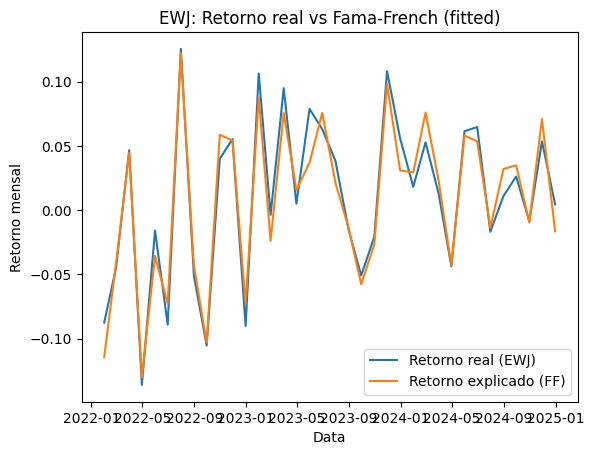

In [33]:
plt.figure()
plt.plot(DATA.index, DATA['adj_close'], label='Retorno real (EWJ)')
plt.plot(DATA.index, DATA['ff_total_return'], label='Retorno explicado (FF)')
plt.legend()
plt.title('EWJ: Retorno real vs Fama-French (fitted)')
plt.xlabel('Data')
plt.ylabel('Retorno mensal')
plt.show()
